In [2]:
def find_max_value(numbers):
    if not numbers:
        return None
    max_value = numbers[0]
    for num in numbers[1:]:
        if num > max_value:
            max_value = num

    return max_value

nums = [10, 45, 23, 67, 12]
result = find_max_value(nums)

if result is None:
    print("List is empty.")
else:
    print("Maximum value:", result)

Maximum value: 67


In [3]:
def count_frequency(elements):
    freq = {}

    for item in elements:
        if item in freq:
            freq[item] += 1
        else:
            freq[item] = 1

    return freq

data = ["apple", "banana", "apple", "orange", "banana", "apple"]
result = count_frequency(data)

print("Frequency of elements:")
for key, value in result.items():
    print(f"{key}: {value}")

Frequency of elements:
apple: 3
banana: 2
orange: 1


In [4]:
import pandas as pd
import numpy as np

df = pd.read_csv("data.csv")

print("First 5 rows:\n", df.head())

print("\nDataset Info:")
print(df.info())

print("\nData Types:\n", df.dtypes)

print("\nSummary Statistics:\n", df.describe())

print("\nMissing Values:\n", df.isnull().sum())

for col in df.select_dtypes(include=np.number).columns:
    df[col].fillna(df[col].median(), inplace=True)

for col in df.select_dtypes(include='object').columns:
    df[col].fillna(df[col].mode()[0], inplace=True)

print("\nAfter Handling Missing Values:\n", df.isnull().sum())

for col in df.select_dtypes(include=np.number).columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    median = df[col].median()
    df[col] = np.where((df[col] < lower) | (df[col] > upper), median, df[col])

print("\nCleaned Dataset:\n", df.head())

First 5 rows:
    customer_id       amount  branch_id                 date
0          151  2975.521478          2  2023-01-01 00:00:00
1          192  3752.653424          2  2023-01-01 01:00:00
2          114  2215.131777          9  2023-01-01 02:00:00
3          171   725.143484          5  2023-01-01 03:00:00
4          160  1490.501938          2  2023-01-01 04:00:00

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 1038 entries, 0 to 1037
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   customer_id  1038 non-null   int64  
 1   amount       1038 non-null   float64
 2   branch_id    1038 non-null   int64  
 3   date         1038 non-null   str    
dtypes: float64(1), int64(2), str(1)
memory usage: 32.6 KB
None

Data Types:
 customer_id      int64
amount         float64
branch_id        int64
date               str
dtype: object

Summary Statistics:
        customer_id        amount    branch_id
count  1038

/tmp/ipykernel_2729/3996290920.py:18: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df[col].fillna(df[col].median(), inplace=True)
/tmp/ipykernel_2729/3996290920.py:18: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to

Slope (Coefficient): 0.32787878787878794
Intercept: -1.2909090909090928
Predicted spend for 85k income: 26.58k
Predicted spend for 90k income: 28.22k
Predicted spend for 26k income: 7.23k
Predicted spend for 200k income: 64.28k
Predicted spend for 10k income: 1.99k


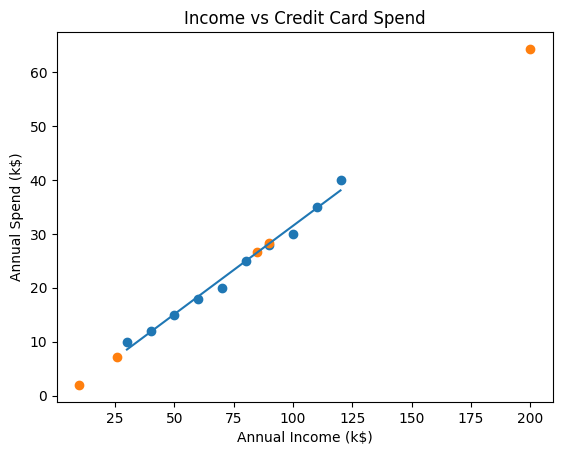

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

X = np.array([30,40,50,60,70,80,90,100,110,120]).reshape(-1,1)
y = np.array([10,12,15,18,20,25,28,30,35,40])

model = LinearRegression()

model.fit(X, y)

slope = model.coef_[0]
intercept = model.intercept_

print("Slope (Coefficient):", slope)
print("Intercept:", intercept)

test_values = np.array([85, 90, 26, 200, 10]).reshape(-1,1)
predictions = model.predict(test_values)

for i, val in enumerate(test_values):
    print(f"Predicted spend for {val[0]}k income: {predictions[i]:.2f}k")

plt.scatter(X, y)
plt.plot(X, model.predict(X))
plt.scatter(test_values, predictions)

plt.xlabel("Annual Income (k$)")
plt.ylabel("Annual Spend (k$)")
plt.title("Income vs Credit Card Spend")

plt.show()